In [15]:
suppressWarnings(
  suppressPackageStartupMessages({
    library(misha)
    library(misha.ext)
    library(zoo)
    library(tglkmeans)
    library(data.table)
    library(tidyverse)
    library(tgstat)
    library(prego)
    library(tgutil)
    library(here)
    library(pheatmap)
  })
)

options(gmax.data.size = 1e10)
options(gmultitasking = FALSE)

link_dir =  paste0(here(),'/')
setwd(here())
gsetroot(paste0(link_dir,'data/mm10/'))
gdb.reload()

source(paste0(link_dir,'code/seq2epi_utils.r'))
source(paste0(link_dir,'code/fig_fun.r'))

We built a mechanistic model that uses sequence-encoded genomic rules
to predict the pluripotent epigenome with high accuracy.

We next examine the model’s errors to understand what they reveal about
the system. 

We identified two main sources of prediction inaccuracies in the
seed-and-spread model:

1. **Seed misclassification** – some loci are incorrectly classified (second phase of our algorithm).
2. **Spreading errors** – inaccuracies in the predicted spreading
   from correctly identified seeds( third phase of the algorithm).
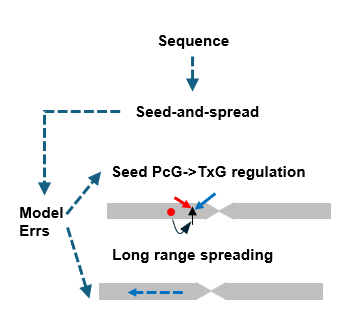

In [8]:
mod = init_pipe()
mod$epi_tss = mod$tss

mod$gw = list()
mod$gw$cg_trace = readRDS('./data/files/cg_trace_mm10.rds')

mod$gw$feats = readRDS('./data//files/feats_mm10.rds')
mod$gw$feats_iqdn = readRDS('./data//files/feats_iqdn_mm10.rds')

done track quant

done cnt track quant

done lib



**Fig. 3B. Impact of gene regulation.**

Normalized epiblast gene expression (Y axis; log2 RNA count fractions)
is shown for loci where the model overestimates or underestimates
PcG occupancy at transcription start sites (TSSs).

Overestimation of PcG occupancy by the sequence-based model
is primarily observed at actively transcribed TSSs.

This likely reflects the influence of cis-regulatory elements
not included in the model that promote TrxG recruitment.

[1] 161  16

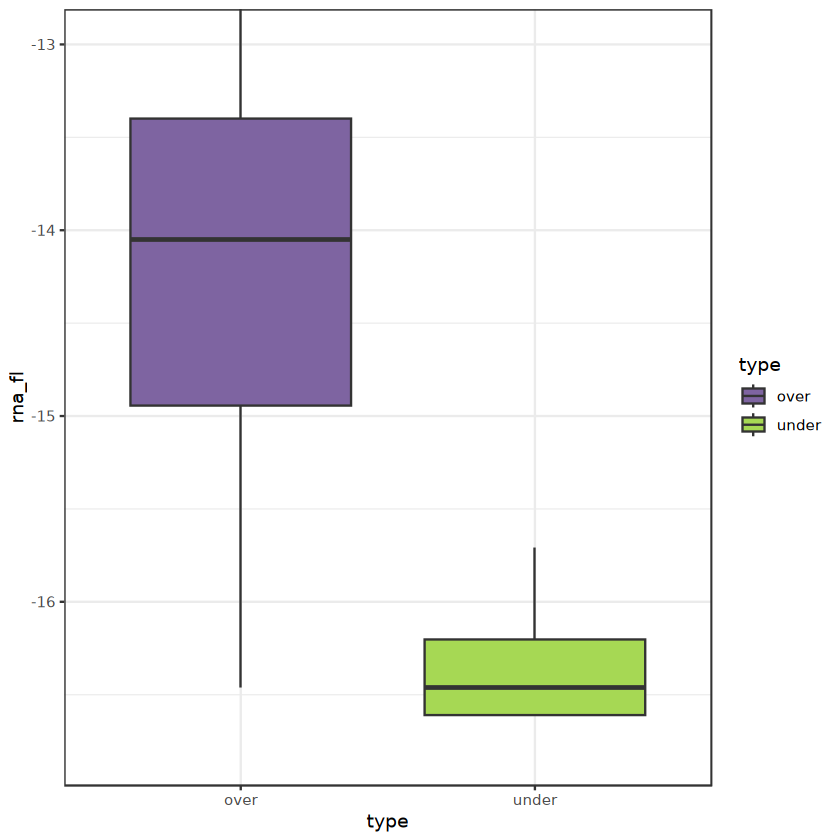

In [9]:
#we noticed minor difference between current TableS1 and the one we provided with the paper. The current is right.
#We will fix this
if (file.exists('./data/files/TableS1.csv')) {
 
  df_d = read.csv('./data//files/TableS1.csv')
    dim(df_d)
} else {
   
df_d = gen_tableS1()
write.csv(df_d,'./data//files/TableS1.csv')
dim(df_d)
}
plt = function(x){df_d %>% ggplot(aes(x= type, y= rna_fl,fill=type)) + geom_boxplot(outlier.shape = NA)+theme_bw()+
  scale_fill_manual(values = c("#7E64A1", "#A6D854"))+coord_cartesian(ylim = c(-16.8,-13))

}
gg = plt()
print(gg)
save_baseR_to_ppt(plot_func = plot(1,1),link_ppt = './figs/over_vs_under_misses_boxplot.pptx')

# scale_fill_gradient(low = "lightblue", high = "darkblue")

save_gg_to_ppt(gg = gg,link = './figs/over_vs_under_misses_boxplot.pptx')

**Fig. 3C. Tgif1 region.**

Example of model overestimation of PcG occupancy at an expressed gene.

Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/Tgif1_overshoot.pptx



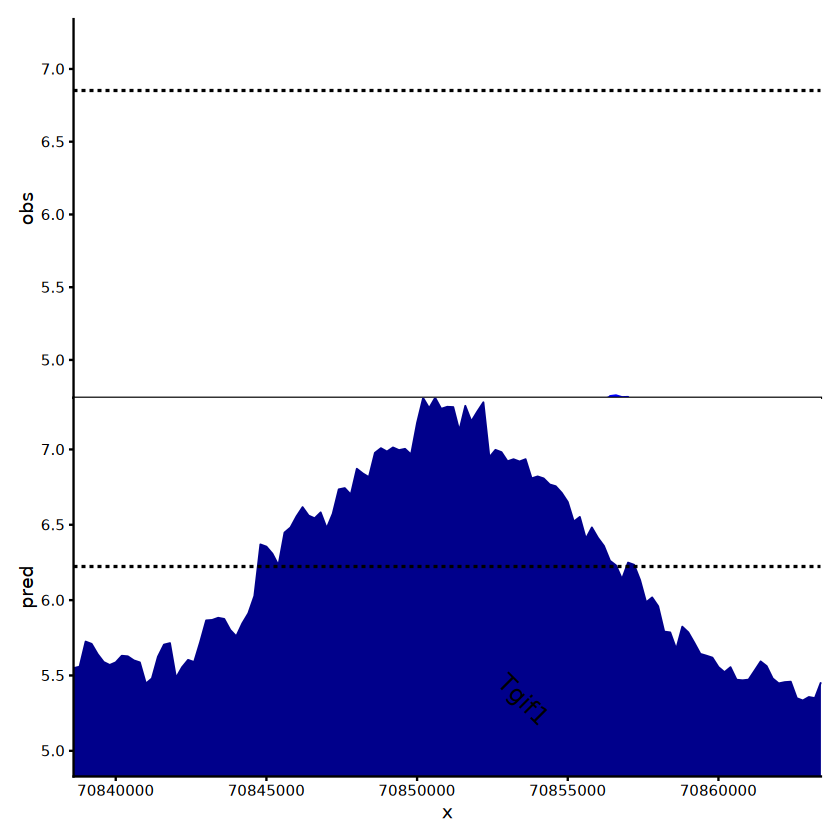

In [10]:
horiz =1e4
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz-5e3, off3 = horiz,mark_reg = c(NA),
				chrom = as.character('chr17'), locus =70853545, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/Tgif1_overshoot.pptx')
plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz-5e3, off3 = horiz,mark_reg = c(NA),
				chrom = as.character('chr17'), locus =70853545, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c())

**Fig. 3E and Fig. S6A. Spreading errors.**



In [11]:
mod = pcg_pred_misses(mod = mod,gap_T = 2.5)

`summarise()` has grouped output by 'chrom'. You can override using the
`.groups` argument.


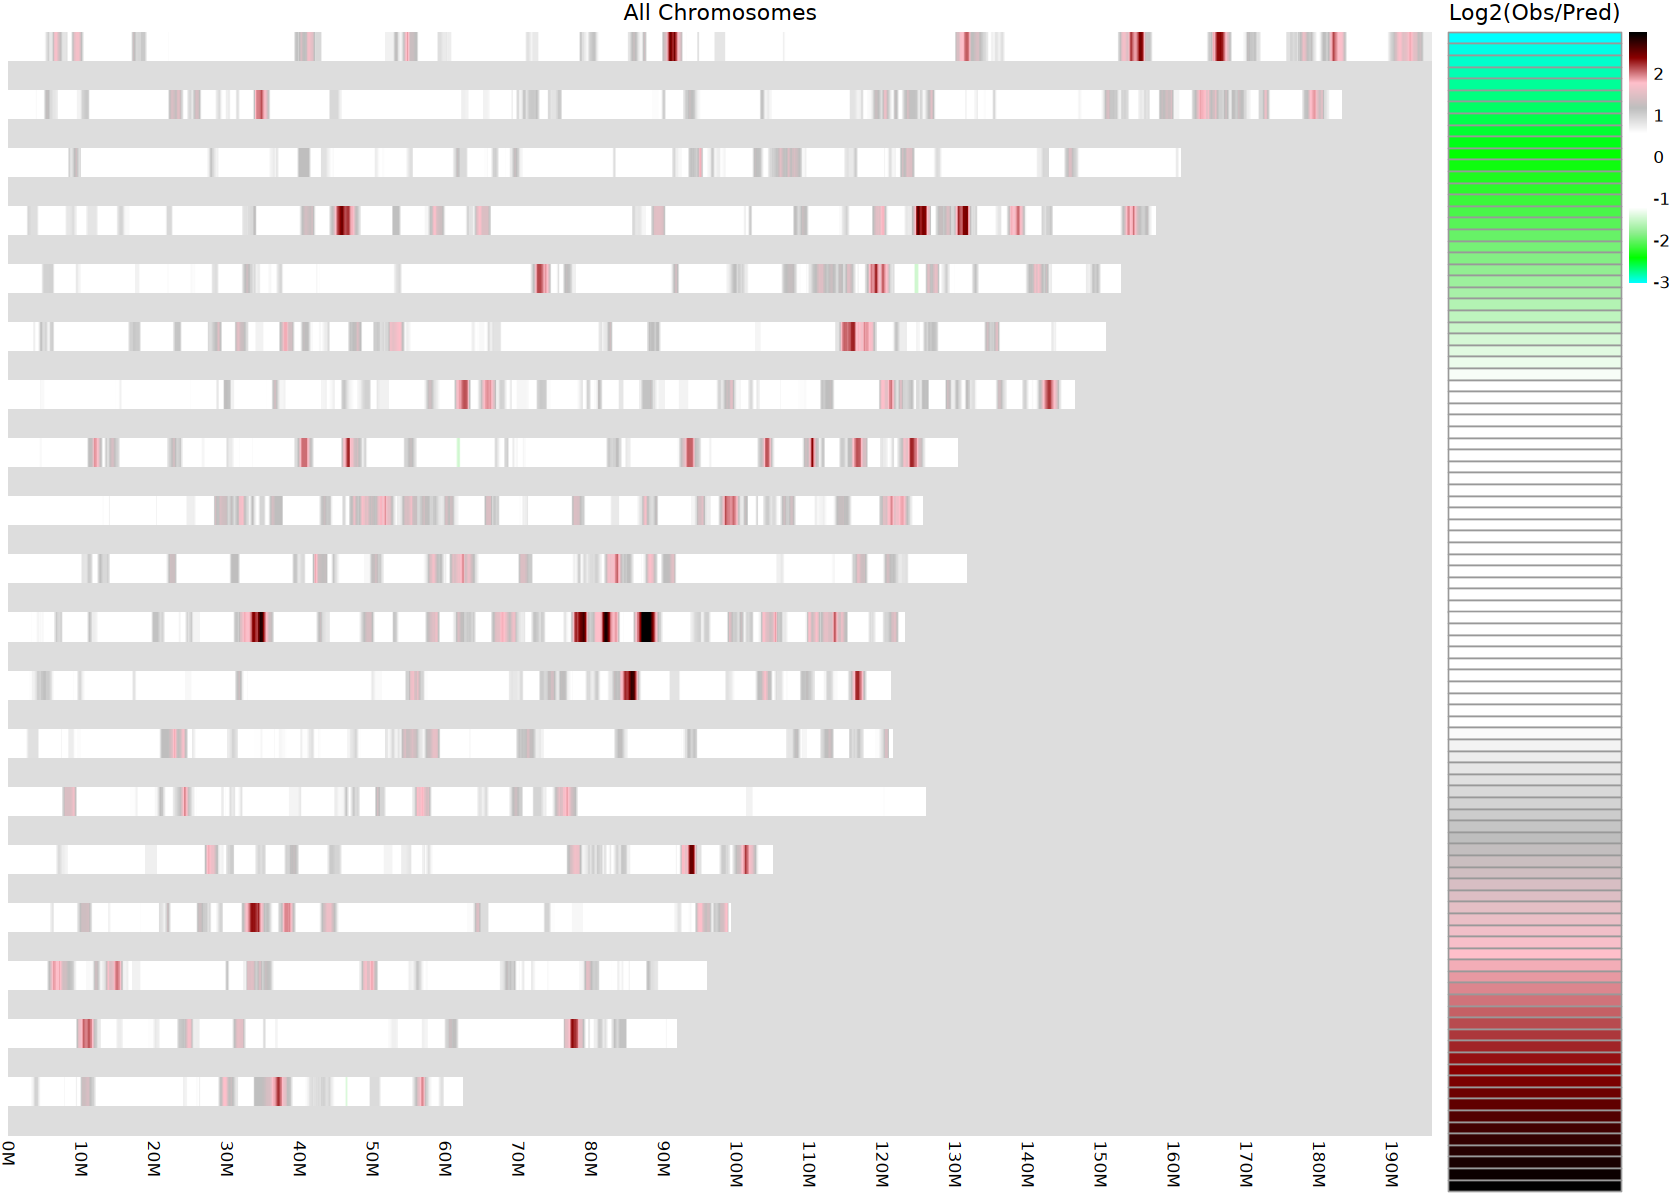

In [13]:
sps(14,10)
nested = pcg_test_miss_over_chroms_fcs_no_pred(mod)

`summarise()` has grouped output by 'chrom'. You can override using the
`.groups` argument.


Focusing on chr7 (chromosome 7 )


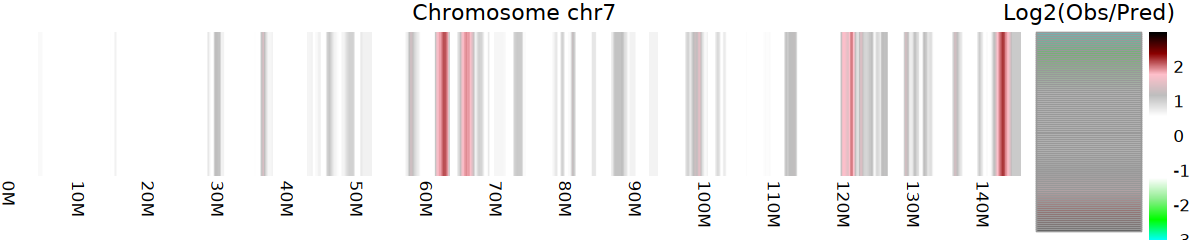

In [10]:
options( repr.plot.width=10,repr.plot.height=2)
nested = pcg_test_miss_over_chroms_fcs_no_pred(mod,focus_chrom = 'chr7')



Examples of spreading errors

In [ ]:
horiz = .5e6
plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz-2.2e5,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =143254456, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c())
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz-2.2e5,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =143254456, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/chr7_kcnq_zoom.pptx')

horiz = .3e6
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz-.5e5, off3 = horiz-1.1e5,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =62464509, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/chr7_peg12_zoom.pptx')

horiz = 1e6
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =66000000, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/chr7_midpannel.pptx')



horiz = 1.0e6
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =99000000, 
				label_tss = F,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/chr7_other_zoom.pptx')
horiz = 1.0e6
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =99000000, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/chr7_other_zoom_tss.pptx')

horiz = .5e6
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =37500000, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/chr7_37MB_tss.pptx')
horiz = .5e6
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =37500000, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/chr7_37MB.pptx')

horiz = 1.05e6
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =136000000, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/chr7_136MB_tss.pptx')
horiz = .5e6
save_gg_to_pptx(plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,mark_reg = c(NA),
				chrom = as.character('chr7'), locus =136000000, 
				label_tss = T,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),path = './figs/chr7_136MB.pptx')

### Generation of Table S2 and classification of model errors

In [13]:
if (file.exists('./data/miss3_fig3.rds')) {
  # do 1
  miss3 = readRDS('./data/miss3_fig3.rds')
} else {
  miss3 = annotate_misses()
  saveRDS(miss3,'./data/miss3_fig3.rds')
}

table(miss3$type2)



temp = miss3[,c('chrom','start','end','l','g','g_dist','cg','gc','d_ltr','d_sine','d_line','simp_d','lowcomplex_d',
            'type','type2' )]

#write.csv(temp,'./data/tableS2.csv') 


       cgdd intcg_close   intcg_far lowcg_close   lowcg_far         rpt 
         89          23          16          96          21           4 

**Fig. 3D. Chromosomal contact enrichment map (as in Bonev et al.) for a region on chromosome 2.**

Hi-C tracks are very heavy.
Therefore, we provide precomputed data here to reproduce
only the Hi-C plot shown in the main figure.

set vt for marginal



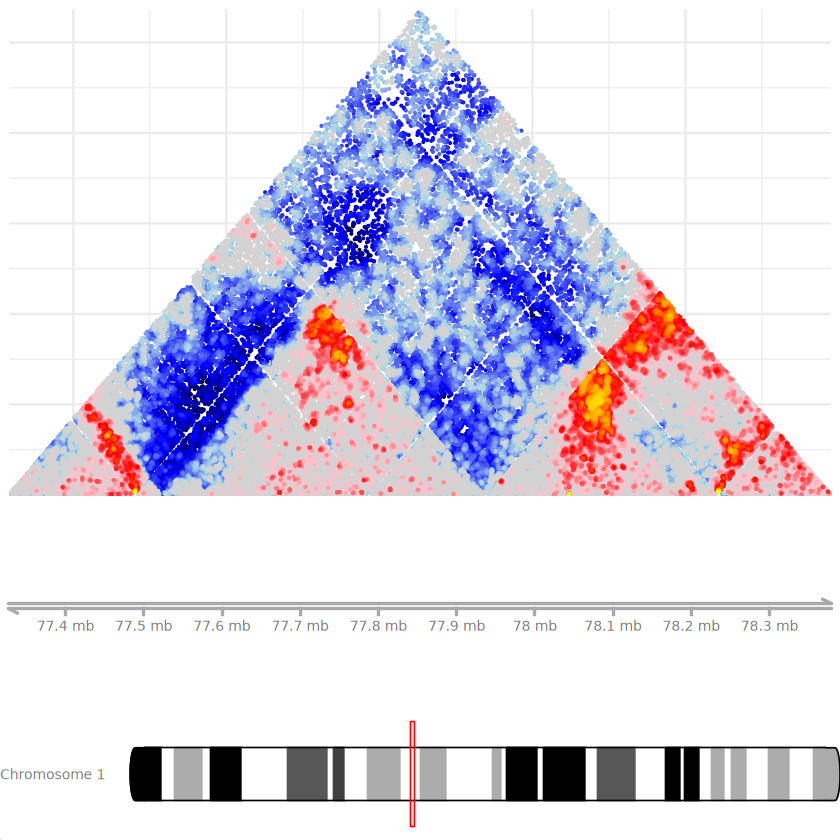

In [10]:
library(shaman)
gen_track_vext()
gen_k27_vt(mod)
chr = 'chr1'
st = 77516192
en = 78189965
ext <- 2e5
# point_score <- gextract(
#     "hic.ES.gc_es_score",
#     gintervals.2d(chr, st - ext, en + ext, chr, st - ext, en + ext),
#     colnames = "score"
# )
point_score = readRDS('./data/point_score_fig3D_HiC.rds')
shaman_plot_map_score_with_annotations(
        "mm10",annotations = c(),
        add_genes = FALSE,
        point_score,
        gintervals(chr, st - ext, en + ext),
        misha_tracks = list(),
        a_colors = c()
    )


Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/miss_fig3_chr2_158802381_160367812.pptx



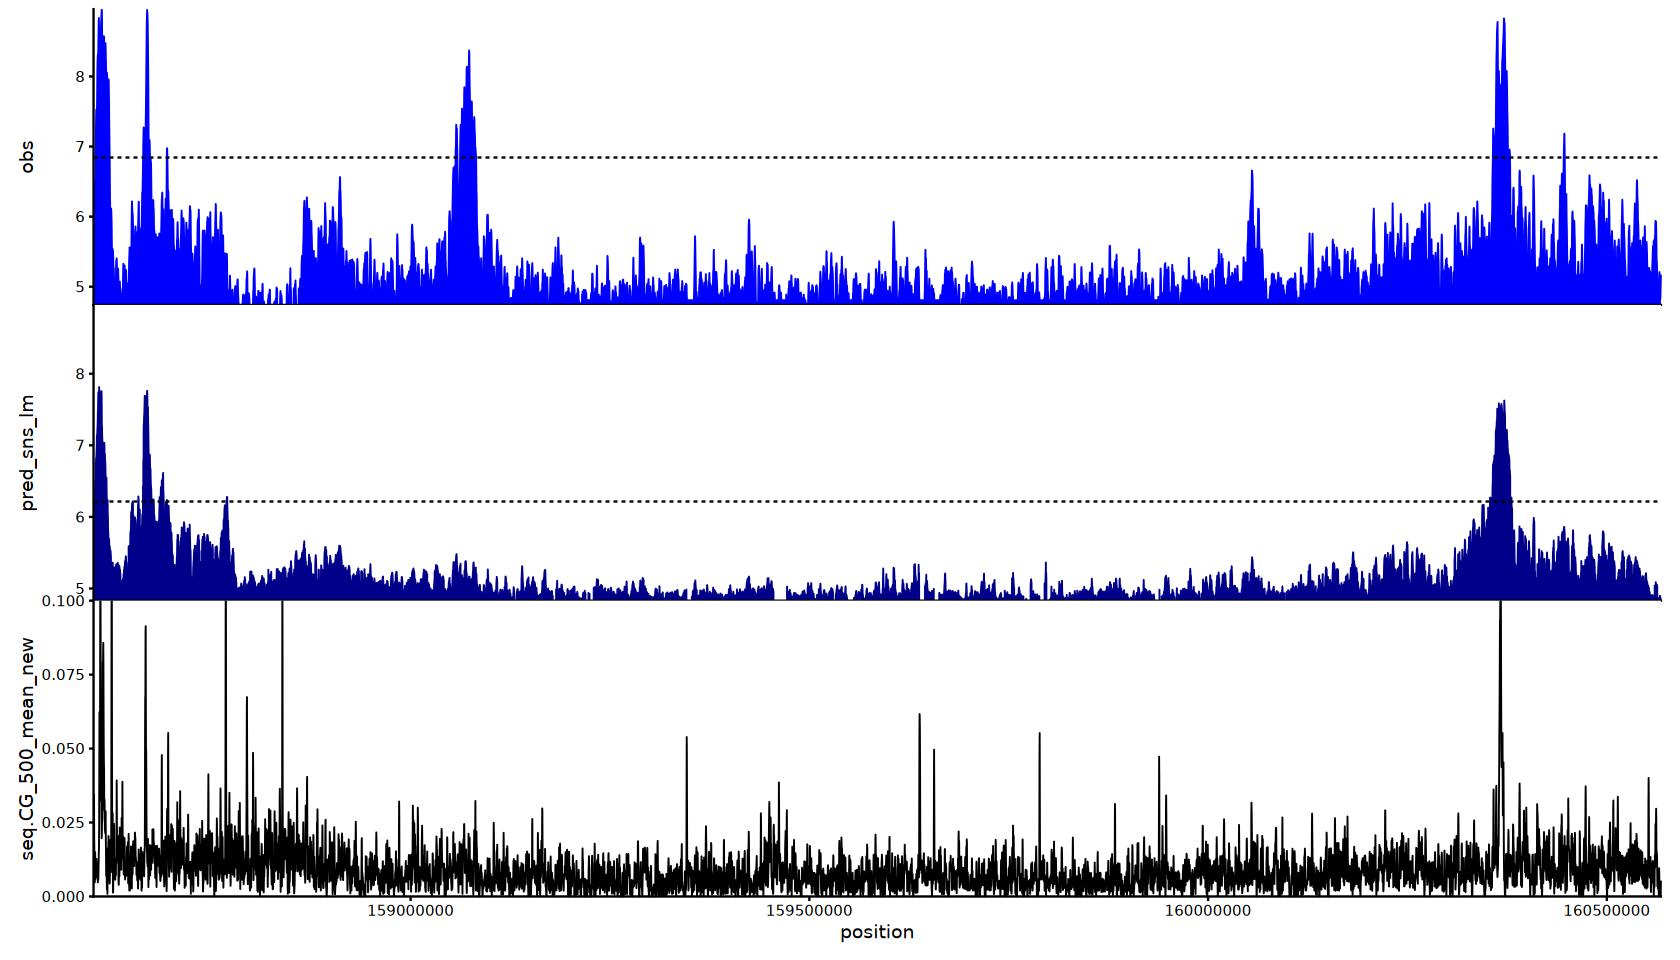

In [14]:
sps(14,8)
chr = 'chr2'
st = 158802381
en = 160367812
ext <- 2e5
gg = plt_genome_pred_CG_ppt_st_end_borzoi_forA_lm_cg_gg(mod, g = NA, off5 = -ext, off3 = ext,mark_reg = c(NA),
				chrom = as.character(chr), start = st,end=en, 
				label_tss = F,
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c('seq.CG_500_mean_new'))
save_gg_to_pptx(gg,path = './figs/miss_fig3_chr2_158802381_160367812.pptx')
gg

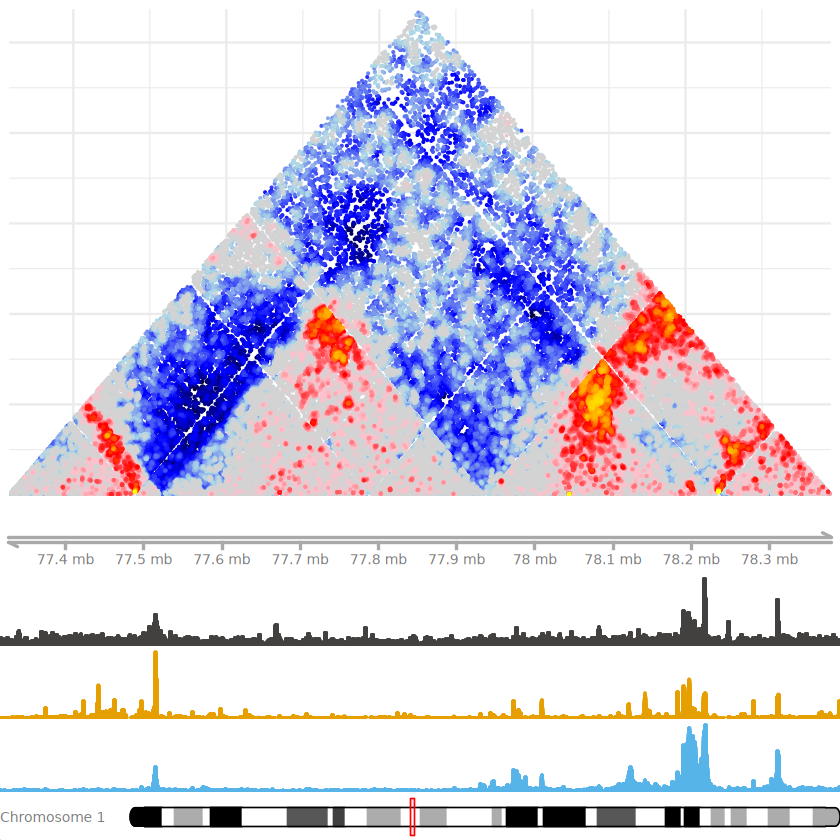

In [44]:
chr = 'chr1'
st = 77516192
en = 78189965
ext <- 2e5

    point_score <- gextract(
        "hic.ES.gc_es_score",
        gintervals.2d(chr, st - ext, en + ext, chr, st - ext, en + ext),
        colnames = "score"
    )

    shaman_plot_map_score_with_annotations(
        "mm10",annotations = c(),
  add_genes = FALSE,
        point_score,
        gintervals(chr, st - ext, en + ext),
        misha_tracks = list("seq.CG_500_mean_new", 'atac_ext', "EB4_cnt"),
        a_colors = c("#4572A7", "blue")
    )


### hg19 analysis (Fig. 3F–G and Fig. S6B)

In [15]:
gsetroot(paste0(link_dir,'data/hg19/'))

gdb.reload()

source(paste0(here(),'/code/hgpcg_domains_hg19.r'))
source(paste0(here(),'/code/fig_fun.r'))

mod = hpcg_init()

cgdd_iq = fread(here("output/iq-hg19-model_preds-diff-preds.tsv"), sep = "\t")%>%
arrange(chrom,start)
mod$cgdom_ann$ID = 1:nrow(mod$cgdom_ann)






set vt for marginal



In [16]:
mod$gw$cg_trace = readRDS(paste0(here(),'/data/files_hg19/cg_trace.rds'))

`summarise()` has grouped output by 'chrom'. You can override using the
`.groups` argument.


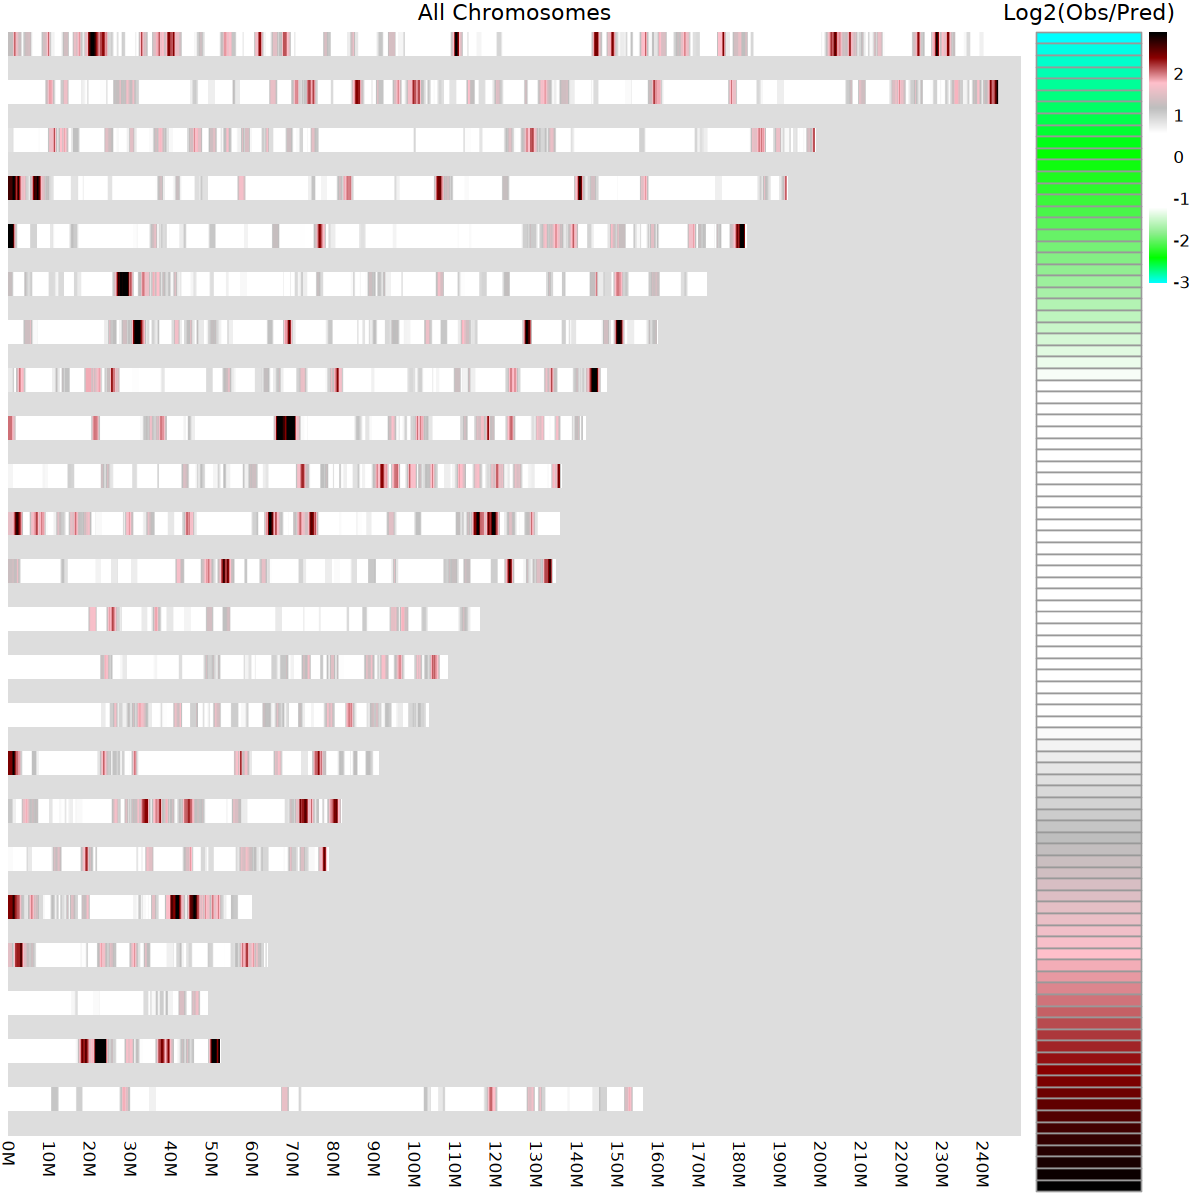

In [32]:
options( repr.plot.width=10,repr.plot.height=10)
nested = pcg_test_miss_over_chroms_fcs_no_pred_hg(mod)

`summarise()` has grouped output by 'chrom'. You can override using the
`.groups` argument.


Focusing on chr19 (chromosome 19 )


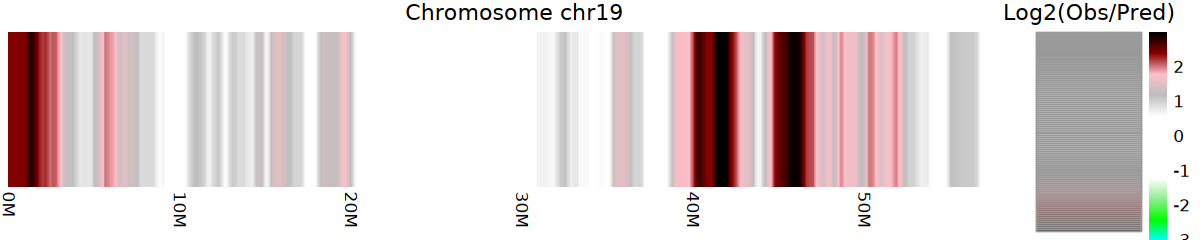

In [23]:
options( repr.plot.width=10,repr.plot.height=2)
nested = pcg_test_miss_over_chroms_fcs_no_pred_hg(mod,focus_chrom = 'chr19')


`summarise()` has grouped output by 'chrom'. You can override using the
`.groups` argument.


Focusing on chr22 (chromosome 22 )


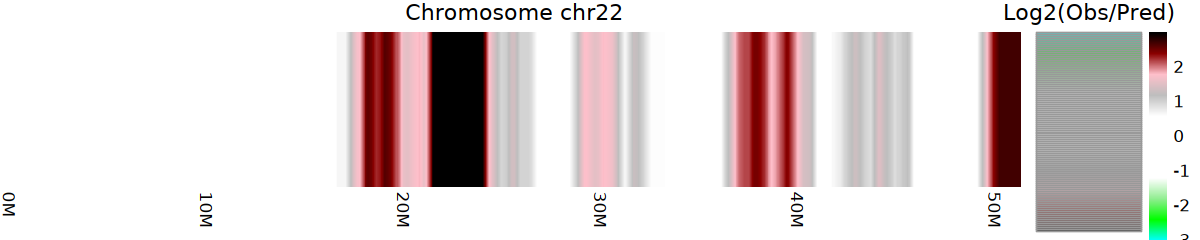

In [18]:
options( repr.plot.width=10,repr.plot.height=2)
nested = pcg_test_miss_over_chroms_fcs_no_pred_hg(mod,focus_chrom = 'chr22')

In [80]:
options( repr.plot.width=10,repr.plot.height=2)
nested = pcg_test_miss_over_chroms_fcs_no_pred_hg(mod,fn = './figs/kryo_all_hg.png')

`summarise()` has grouped output by 'chrom'. You can override using the
`.groups` argument.


In [25]:
mod$epi_tss = mod$tss

mod$epi_tss$geneSymbol = mod$epi_tss$name

NULL

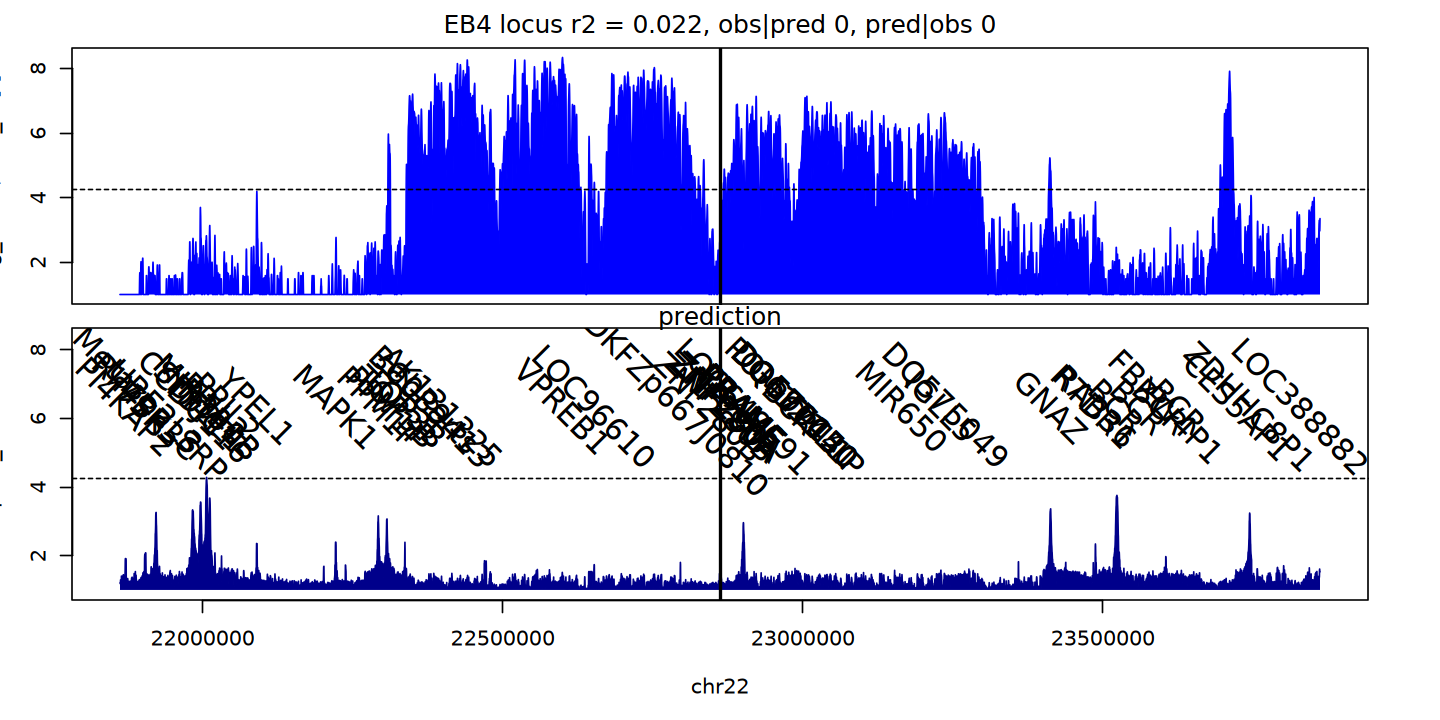

In [31]:
 horiz=1e6#5.5e6
save_baseR_to_ppt(plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = T,
				chrom = as.character('chr19'), locus =3450000, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),'./figs/GW_chr19.pptx')

horiz=1e6#5e6
plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = T,
				chrom = as.character('chr22'), locus =23062000-2e5, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c())
save_baseR_to_ppt(plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = T,
				chrom = as.character('chr22'), locus =23062000-2e5, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),'./figs/GW_chr22.pptx')

NULL

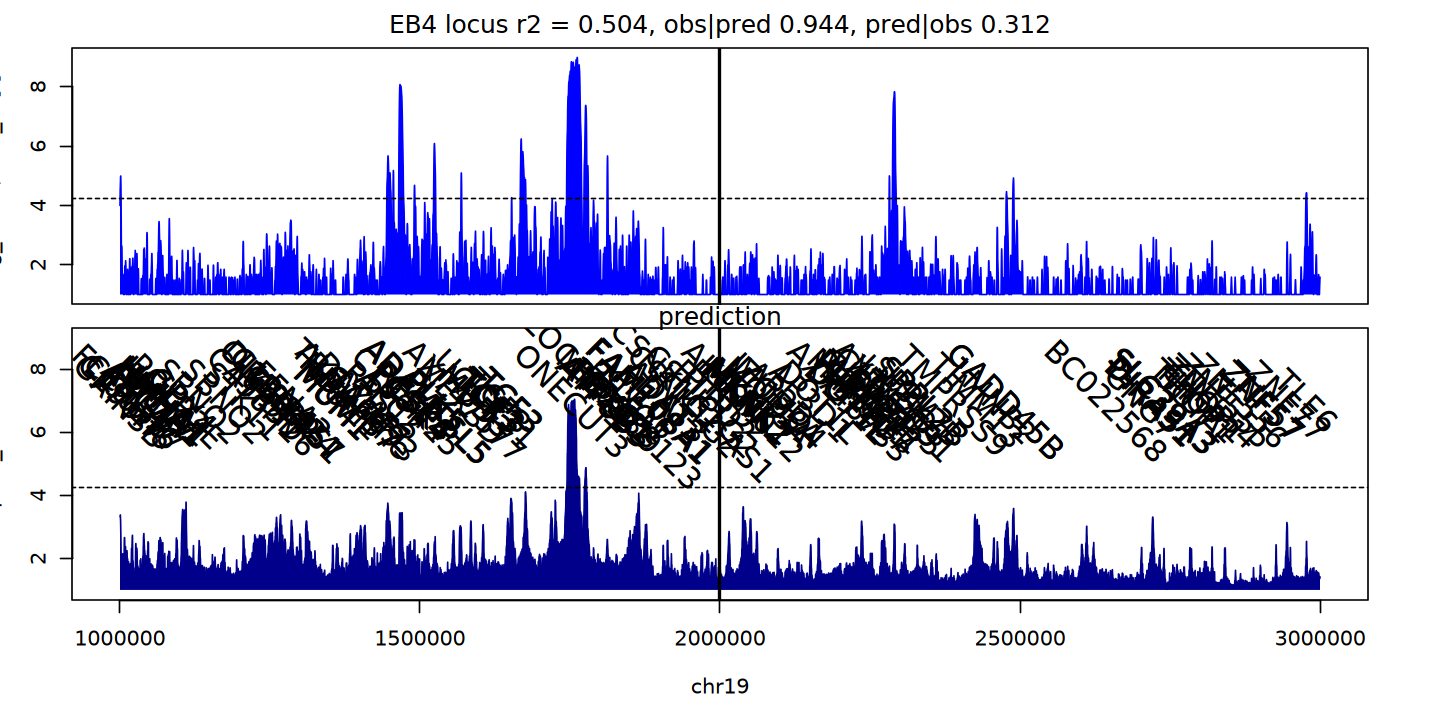

In [29]:
 horiz=1e6#5.5e6
plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = T,
				chrom = as.character('chr19'), locus =2e6, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c())
save_baseR_to_ppt((plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = T,
				chrom = as.character('chr19'), locus =2e6, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c())),'./figs/GW_chr19_use.pptx')